In [1]:
# Session 14
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('cleaned_cp_dataset.csv')

In [3]:
sample_materials = df['formula'].unique()[:5]

In [5]:
print(df.columns)

Index(['Material_ID', 'formula', 'Band_Gap', 'Formation_Energy_Per_Atom',
       'Volume'],
      dtype='object')


In [9]:
print(df.columns.tolist())

['Material_ID', 'formula', 'Band_Gap', 'Formation_Energy_Per_Atom', 'Volume']


In [10]:
df.columns = df.columns.str.strip()
print(df.columns.tolist())

['Material_ID', 'formula', 'Band_Gap', 'Formation_Energy_Per_Atom', 'Volume']


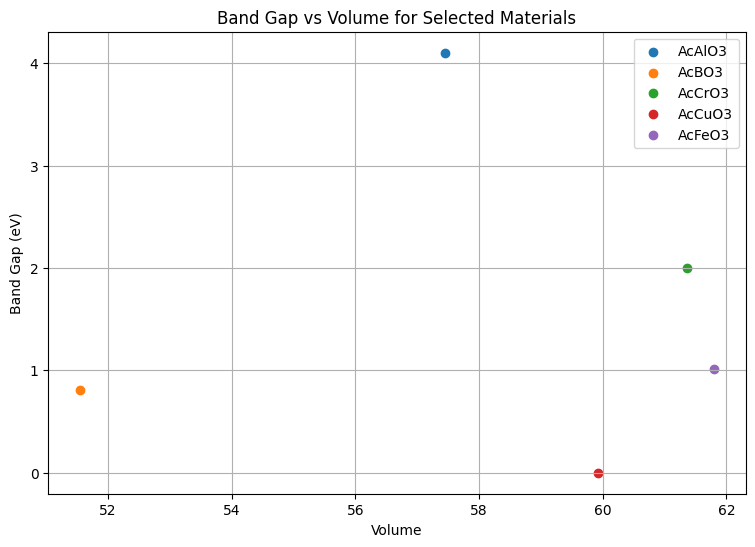

In [12]:
plt.figure(figsize=(9, 6))

for mat in sample_materials:
    subset = df[df['formula'] == mat]
    plt.scatter(subset['Volume'], subset['Band_Gap'], label=mat)

plt.title('Band Gap vs Volume for Selected Materials')
plt.xlabel('Volume')
plt.ylabel('Band Gap (eV)')
plt.legend()
plt.grid(True)
plt.show()

In [14]:
def classify_family(formula):
    if 'O' in formula and 'C' not in formula and 'N' not in formula:
        return 'Oxide'
    elif 'C' in formula:
        return 'Carbide'
    elif 'N' in formula:
        return 'Nitride'
    else:
        return 'Other'

df['family'] = df['formula'].apply(classify_family)

df_grouped = df[df['family'].isin(['Oxide', 'Carbide', 'Nitride'])]

family_stats = df_grouped.groupby('family')['Band_Gap'].agg(['mean', 'std']).reset_index()

print(family_stats)

    family      mean       std
0  Carbide  1.050767  1.626854
1  Nitride  0.837091  1.347730
2    Oxide  1.322893  1.636592
